In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt



In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [5]:
# Check.for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [7]:
df = pd. read_csv('fashion-mnist_train.csv')
df. head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df.shape

(60000, 785)

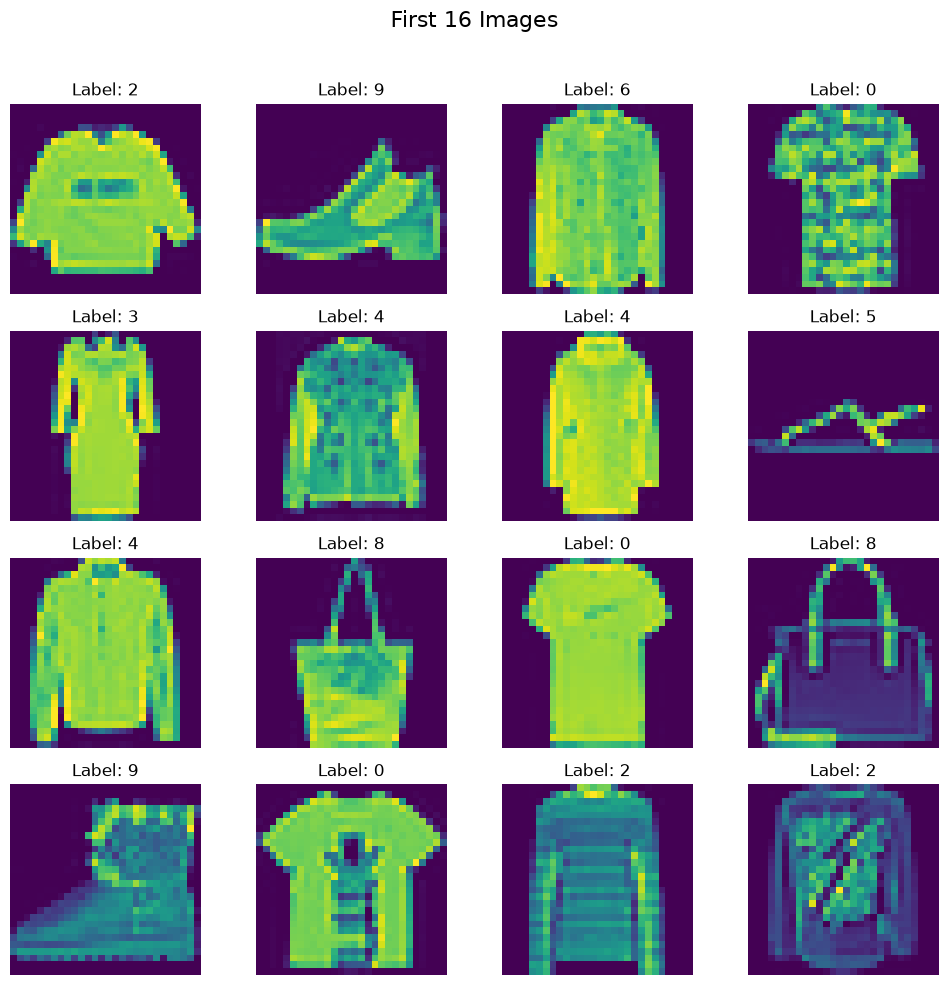

In [10]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [11]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train = X_train/255.0
X_test = X_test/255.0

In [14]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [15]:
train_dataset = CustomDataset(X_train, y_train)

In [16]:
test_dataset = CustomDataset(X_test, y_test)

In [17]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [18]:
len(train_loader)

1500

In [19]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)

    )

  def forward(self, x):

    return self.model(x)


In [20]:
learning_rate = 0.1
epochs = 100

In [21]:
# instatiate the model
model = MyNN(X_train.shape[1])
model = model.to(device)
# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [22]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.6351939877172311
Epoch: 2 , Loss: 0.42993330796062945
Epoch: 3 , Loss: 0.38716355346888304
Epoch: 4 , Loss: 0.35921751268208024
Epoch: 5 , Loss: 0.3373533294101556
Epoch: 6 , Loss: 0.3234642747764786
Epoch: 7 , Loss: 0.3092729019274314
Epoch: 8 , Loss: 0.2963098630184929
Epoch: 9 , Loss: 0.2868141720071435
Epoch: 10 , Loss: 0.2750636451219519
Epoch: 11 , Loss: 0.2704818857833743
Epoch: 12 , Loss: 0.2596491933017969
Epoch: 13 , Loss: 0.24975113554795583
Epoch: 14 , Loss: 0.24340801678970456
Epoch: 15 , Loss: 0.23749119540055594
Epoch: 16 , Loss: 0.23367439925049743
Epoch: 17 , Loss: 0.22486351669579743
Epoch: 18 , Loss: 0.2215577500537038
Epoch: 19 , Loss: 0.21426124619816742
Epoch: 20 , Loss: 0.21029086328918736
Epoch: 21 , Loss: 0.2073453726855417
Epoch: 22 , Loss: 0.20354699421984454
Epoch: 23 , Loss: 0.19708647969116766
Epoch: 24 , Loss: 0.19394648717964688
Epoch: 25 , Loss: 0.18785488668829203
Epoch: 26 , Loss: 0.18239362284292776
Epoch: 27 , Loss: 0.180048295573

In [26]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print((correct/total)*100,"%")

88.25 %


In [27]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print((correct/total)*100,"%")

97.98750000000001 %


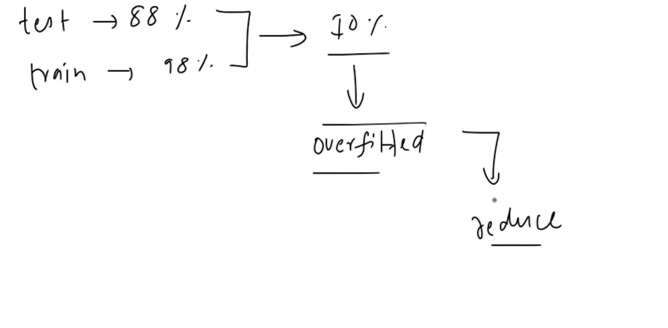

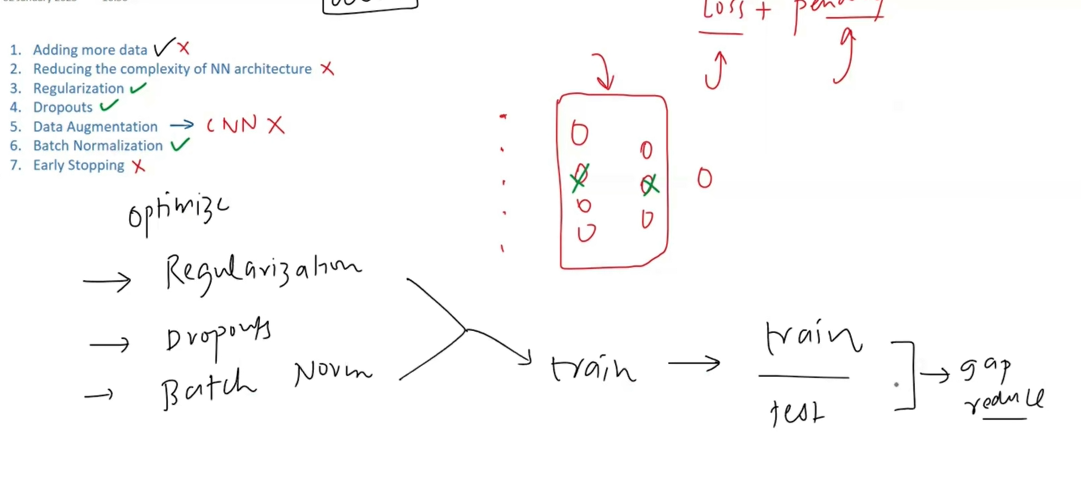

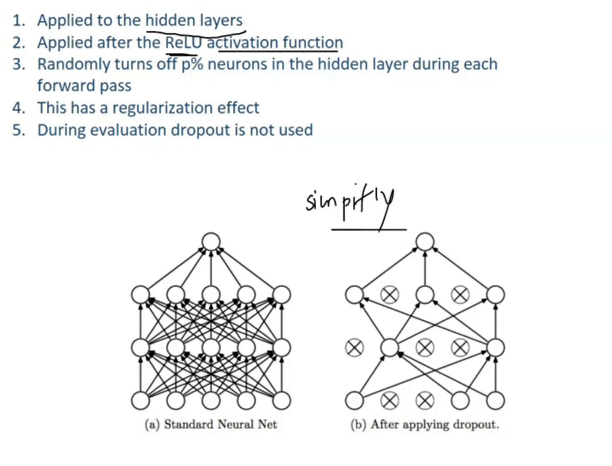

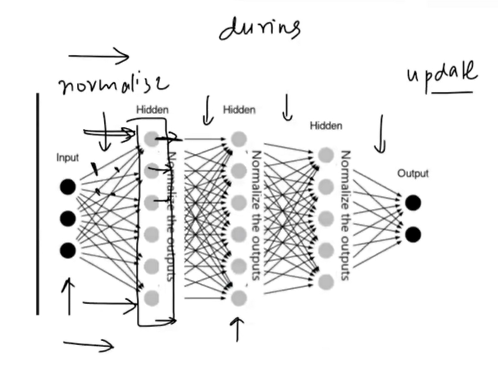

In [36]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(64, 10)

    )

  def forward(self, x):

    return self.model(x)


In [37]:
learning_rate = 0.1
epochs = 100

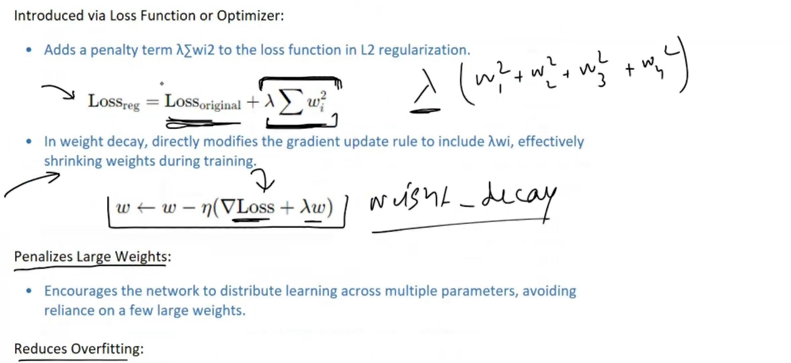

In [38]:
# instatiate the model
model = MyNN(X_train.shape[1])
model = model.to(device)
# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate,weight_decay=1e-4)

In [39]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.6240217074751854
Epoch: 2 , Loss: 0.4982247482935588
Epoch: 3 , Loss: 0.45813799058894317
Epoch: 4 , Loss: 0.4346139128456513
Epoch: 5 , Loss: 0.4151806198110183
Epoch: 6 , Loss: 0.40321031982203326
Epoch: 7 , Loss: 0.3969298325876395
Epoch: 8 , Loss: 0.3854850507179896
Epoch: 9 , Loss: 0.3752975258131822
Epoch: 10 , Loss: 0.37297397404909133
Epoch: 11 , Loss: 0.3611483955780665
Epoch: 12 , Loss: 0.35587636345624923
Epoch: 13 , Loss: 0.3546333504865567
Epoch: 14 , Loss: 0.34934252449870107
Epoch: 15 , Loss: 0.3440468245446682
Epoch: 16 , Loss: 0.34198315238952637
Epoch: 17 , Loss: 0.33526591530938943
Epoch: 18 , Loss: 0.33581721832354866
Epoch: 19 , Loss: 0.3324799188623826
Epoch: 20 , Loss: 0.32699750759700935
Epoch: 21 , Loss: 0.32518442763388156
Epoch: 22 , Loss: 0.323483017389973
Epoch: 23 , Loss: 0.3201673979113499
Epoch: 24 , Loss: 0.3162083484431108
Epoch: 25 , Loss: 0.31657801471402247
Epoch: 26 , Loss: 0.3142358391160766
Epoch: 27 , Loss: 0.3123655814702312


In [41]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [42]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print((correct/total)*100,"%")

89.39166666666667 %


In [43]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print((correct/total)*100,"%")

94.64375000000001 %


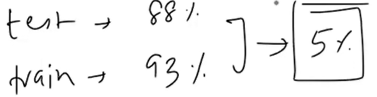